In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
!pip install -q ultralytics sahi supervision opencv-python yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 13.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 59.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.6 MB/s eta 0:00:00


In [4]:
import os
import urllib.request

# Sample copyright-free drone overhead footage of people walking in open terrain
VIDEO_URL = "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4"
INPUT_VIDEO = "/kaggle/working/drone_feed_input.mp4"

if not os.path.exists(INPUT_VIDEO):
    print("Downloading sample drone test video...")
    urllib.request.urlretrieve(VIDEO_URL, INPUT_VIDEO)
    print("Download complete!")

Download complete!


In [5]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

class DroneSurvivorDetector:
    def __init__(self, model_name="yolov8m.pt", conf_thresh=0.25, use_sahi=False):
        """
        model_name: Pretrained weights ('yolov8n.pt', 'yolov8m.pt', or 'yolo11m.pt')
        conf_thresh: Confidence threshold for survivor detection
        use_sahi: Set to True for extreme high-altitude/small-object detection
        """
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.conf_thresh = conf_thresh
        self.use_sahi = use_sahi
        print(f"Initializing detector on {self.device} (SAHI = {self.use_sahi})...")

        if self.use_sahi:
            self.sahi_model = AutoDetectionModel.from_pretrained(
                model_type="yolov8",
                model_path=model_name,
                confidence_threshold=conf_thresh,
                device=self.device
            )
        else:
            self.model = YOLO(model_name)

    def draw_hud(self, frame, detections, frame_idx, fps):
        """Renders search-and-rescue tactical telemetry overlay."""
        h, w, _ = frame.shape
        survivor_count = len(detections)

        # Draw bounding boxes and target brackets
        for det in detections:
            x1, y1, x2, y2, conf, track_id = det
            color = (0, 0, 255) if conf > 0.4 else (0, 165, 255) # Red for high conf, orange for med

            # Bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # Target Lock label
            label = f"SURVIVOR #{track_id} [{conf:.2f}]" if track_id != -1 else f"SURVIVOR [{conf:.2f}]"
            cv2.putText(frame, label, (x1, max(20, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

            # Crosshairs on detected survivor
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            cv2.drawMarker(frame, (cx, cy), color, markerType=cv2.MARKER_CROSS, markerSize=12, thickness=1)

        # Tactical Status Bar (Top Header)
        cv2.rectangle(frame, (15, 15), (380, 110), (20, 20, 20), -1)
        cv2.rectangle(frame, (15, 15), (380, 110), (0, 255, 0) if survivor_count > 0 else (180, 180, 180), 2)

        status_text = "STATUS: SURVIVOR DETECTED!" if survivor_count > 0 else "STATUS: SEARCHING AREA..."
        status_color = (0, 0, 255) if survivor_count > 0 else (0, 255, 0)

        cv2.putText(frame, "UAV SAR RESCUE FEED", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(frame, status_text, (30, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.55, status_color, 2)
        cv2.putText(frame, f"SURVIVORS IN SIGHT: {survivor_count} | FRAME: {frame_idx}", (30, 92),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)

        return frame

    def process_video(self, input_path, output_path, max_frames=None):
        cap = cv2.VideoCapture(input_path)
        if not cap.isOpened():
            raise ValueError(f"Could not open video file: {input_path}")

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        print(f"Processing video: {width}x{height} @ {fps:.1f} FPS, Total Frames: {total_frames}")

        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or (max_frames and frame_idx >= max_frames):
                break

            detections = []

            if self.use_sahi:
                # SAHI Sliced Inference for tiny targets in high resolution
                result = get_sliced_prediction(
                    frame,
                    self.sahi_model,
                    slice_height=512,
                    slice_width=512,
                    overlap_height_ratio=0.2,
                    overlap_width_ratio=0.2
                )
                for obj in result.object_prediction_list:
                    if obj.category.id == 0:  # Class 0: 'person'
                        box = obj.bbox
                        detections.append([int(box.minx), int(box.miny), int(box.maxx), int(box.maxy), obj.score.value, -1])
            else:
                # Fast Tracking Mode (YOLOv8 + ByteTrack)
                results = self.model.track(
                    frame,
                    persist=True,
                    classes=[0],  # Filter only 'person'
                    conf=self.conf_thresh,
                    verbose=False
                )
                if results[0].boxes is not None and results[0].boxes.xyxy is not None:
                    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
                    confs = results[0].boxes.conf.cpu().numpy()
                    ids = results[0].boxes.id.cpu().numpy().astype(int) if results[0].boxes.id is not None else [-1] * len(boxes)
                    for box, c, tid in zip(boxes, confs, ids):
                        detections.append([box[0], box[1], box[2], box[3], float(c), int(tid)])

            # Draw tactical HUD
            annotated_frame = self.draw_hud(frame, detections, frame_idx, fps)
            out.write(annotated_frame)

            if frame_idx % 30 == 0:
                print(f"Processed frame {frame_idx}/{total_frames} - Survivors Detected: {len(detections)}")

            frame_idx += 1

        cap.release()
        out.release()
        print(f"Video saved to: {output_path}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [6]:
OUTPUT_VIDEO = "/kaggle/working/survivor_detection_output.mp4"

# Set use_sahi=True if the drone is at high altitude and people look like tiny dots
detector = DroneSurvivorDetector(model_name="yolov8m.pt", conf_thresh=0.25, use_sahi=False)

# Run inference (set max_frames=300 to process the first 10-12 seconds quickly)
detector.process_video(input_path=INPUT_VIDEO, output_path=OUTPUT_VIDEO, max_frames=300)

Initializing detector on cuda:0 (SAHI = False)...
Processing video: 768x432 @ 12.0 FPS, Total Frames: 647
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 202ms
Prepared 1 package in 31ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Processed frame 0/647 - Survivors Detected: 0
Processed frame 30/647 - Survivors Detected: 1
Processed frame 60/647 - Survivors Detected: 1
Processed frame 90/647 - Survivors Detected: 0
Processed frame 120/647 - Survivors Detected: 0
Processed frame 150/647 - Survivors Detected: 0
Processed frame 180/647 - Survivors Detected: 0
Processed frame 210/647 - Survivors Detected: 0
Processed frame 240/647 - Survivors Detected: 0
Processed frame 270/647 - Survivors Detected: 0
Video saved to: /kaggle/working/survivor_detection_output.mp4


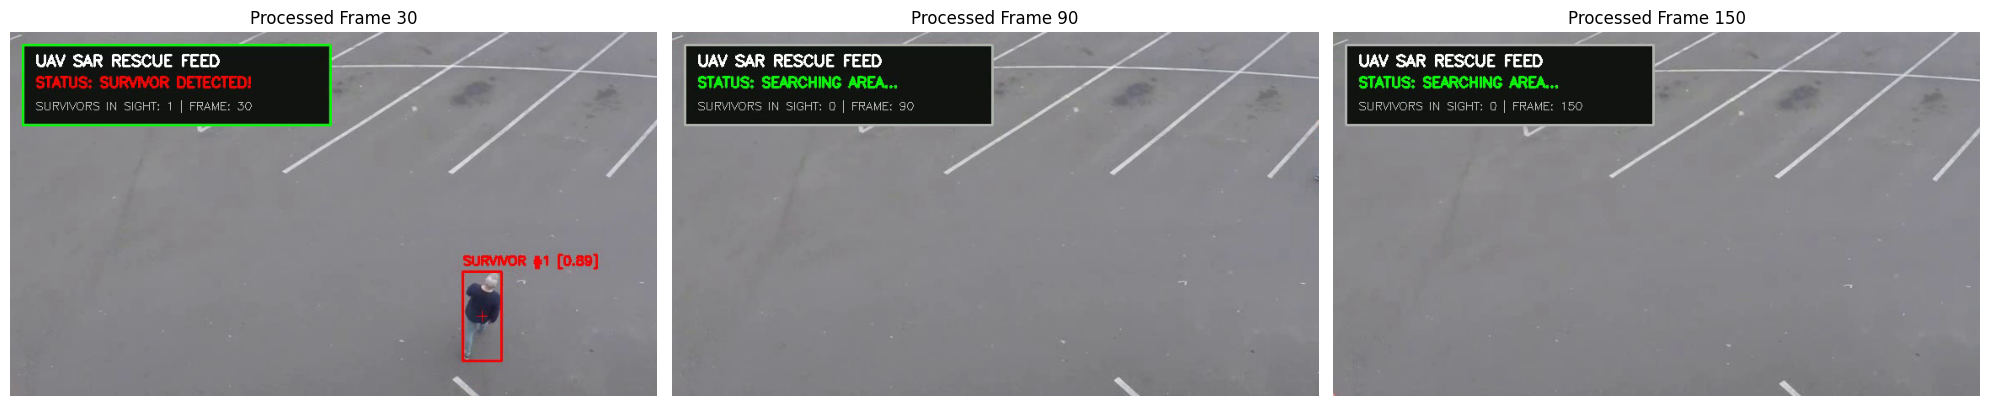

In [7]:
import matplotlib.pyplot as plt

# Extract and display 3 sample frames from the annotated output video
cap = cv2.VideoCapture(OUTPUT_VIDEO)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

frame_indices = [30, 90, 150]
current_idx = 0
plot_idx = 0

while cap.isOpened() and plot_idx < 3:
    ret, frame = cap.read()
    if not ret:
        break
    if current_idx in frame_indices:
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[plot_idx].imshow(rgb_frame)
        axes[plot_idx].set_title(f"Processed Frame {current_idx}")
        axes[plot_idx].axis("off")
        plot_idx += 1
    current_idx += 1

cap.release()
plt.tight_layout()
plt.show()

In [8]:
import os
import glob
from pathlib import Path
import yaml
from ultralytics import YOLO

# Install dependencies
!pip install -q ultralytics albumentations

print("Setting up VisDrone SAR pipeline...")

Setting up VisDrone SAR pipeline...


In [9]:
import shutil
from ultralytics.utils.downloads import download

# 1. Download VisDrone using Ultralytics utility
dataset_dir = Path("/kaggle/working/datasets/VisDrone")
urls = [
    "https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip",
    "https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip"
]
download(urls, dir=dataset_dir)

# 2. Re-engineer labels for SAR Survivor Detection
def reengineer_visdrone_labels(split_dir):
    labels_dir = split_dir / "labels"
    converted_dir = split_dir / "sar_labels"
    converted_dir.mkdir(parents=True, exist_ok=True)
    
    label_files = list(labels_dir.glob("*.txt"))
    print(f"Processing {len(label_files)} annotation files in {split_dir.name}...")

    for f in label_files:
        new_lines = []
        with open(f, "r") as reader:
            for line in reader.readlines():
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                
                # Class 1: pedestrian, Class 2: people
                if cls_id in [1, 2]:
                    # Remap both to 0 (Survivor)
                    new_lines.append(f"0 {' '.join(parts[1:])}\n")
        
        # Write filtered ground truths
        dest_file = converted_dir / f.name
        with open(dest_file, "w") as writer:
            writer.writelines(new_lines)

# Process Train and Val sets
train_path = dataset_dir / "VisDrone2019-DET-train"
val_path = dataset_dir / "VisDrone2019-DET-val"

reengineer_visdrone_labels(train_path)
reengineer_visdrone_labels(val_path)

# 3. Create Custom SAR Dataset YAML
sar_yaml_content = {
    "path": str(dataset_dir),
    "train": "VisDrone2019-DET-train/images",
    "val": "VisDrone2019-DET-val/images",
    "names": {
        0: "survivor"
    }
}

# Link remapped labels to where YOLO expects them
!rm -rf {train_path}/labels_backup
!mv {train_path}/labels {train_path}/labels_backup
!mv {train_path}/sar_labels {train_path}/labels

!rm -rf {val_path}/labels_backup
!mv {val_path}/labels {val_path}/labels_backup
!mv {val_path}/sar_labels {val_path}/labels

sar_yaml_path = "/kaggle/working/sar_visdrone.yaml"
with open(sar_yaml_path, "w") as f:
    yaml.dump(sar_yaml_content, f)

print(f"Dataset YAML written successfully to: {sar_yaml_path}")

Unzipping /kaggle/working/datasets/VisDrone/VisDrone2019-DET-train.zip to /kaggle/working/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.8Kfiles/s 7.1s<0.0s
Unzipping /kaggle/working/datasets/VisDrone/VisDrone2019-DET-val.zip to /kaggle/working/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 2.4Kfiles/s 0.5s0.1s
Processing 0 annotation files in VisDrone2019-DET-train...
Processing 0 annotation files in VisDrone2019-DET-val...
mv: cannot stat '/kaggle/working/datasets/VisDrone/VisDrone2019-DET-train/labels': No such file or directory
mv: cannot stat '/kaggle/working/datasets/VisDrone/VisDrone2019-DET-val/labels': No such file or directory
Dataset YAML written successfully to: /kaggle/working/sar_visdrone.yaml


In [11]:
import os
import glob
from pathlib import Path
from PIL import Image
import yaml

dataset_dir = Path("/kaggle/working/datasets/VisDrone")
train_path = dataset_dir / "VisDrone2019-DET-train"
val_path = dataset_dir / "VisDrone2019-DET-val"

def convert_visdrone_to_sar_yolo(split_dir):
    # Locate original annotations (check 'annotations', 'labels_backup', or 'labels')
    ann_dir = None
    for candidate in ["annotations", "labels_backup", "labels"]:
        p = split_dir / candidate
        if p.exists() and any(p.glob("*.txt")):
            # Check if files have content (> 0 bytes)
            sample = next(p.glob("*.txt"))
            if sample.stat().st_size > 0:
                ann_dir = p
                break

    if not ann_dir:
        raise FileNotFoundError(f"Could not find valid annotation files in {split_dir}")

    dest_labels_dir = split_dir / "sar_labels"
    dest_labels_dir.mkdir(parents=True, exist_ok=True)
    images_dir = split_dir / "images"

    ann_files = list(ann_dir.glob("*.txt"))
    print(f"Converting {len(ann_files)} files from {ann_dir.name} in {split_dir.name}...")

    converted_count = 0
    survivor_box_count = 0

    for ann_file in ann_files:
        # Match image file to obtain dimensions
        img_name = ann_file.stem + ".jpg"
        img_path = images_dir / img_name

        if not img_path.exists():
            continue

        # Fast header-only size read (no decoding overhead)
        with Image.open(img_path) as img:
            img_w, img_h = img.size

        yolo_lines = []
        with open(ann_file, "r") as f:
            for line in f:
                parts = [p.strip() for p in line.strip().split(",") if p.strip()]
                if len(parts) < 8:
                    continue

                bbox_left = float(parts[0])
                bbox_top = float(parts[1])
                bbox_w = float(parts[2])
                bbox_h = float(parts[3])
                score = int(parts[4])
                category = int(parts[5])

                # VisDrone: Class 1 = pedestrian, Class 2 = people
                # score 0 = ignored region
                if category in [1, 2] and score > 0 and bbox_w > 2 and bbox_h > 2:
                    # Convert to normalized xywh format
                    x_center = (bbox_left + bbox_w / 2.0) / img_w
                    y_center = (bbox_top + bbox_h / 2.0) / img_h
                    norm_w = bbox_w / img_w
                    norm_h = bbox_h / img_h

                    # Clip to valid [0, 1] range
                    x_center = max(0.0, min(1.0, x_center))
                    y_center = max(0.0, min(1.0, y_center))
                    norm_w = max(0.0, min(1.0, norm_w))
                    norm_h = max(0.0, min(1.0, norm_h))

                    # Map to single class: 0 (Survivor)
                    yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")
                    survivor_box_count += 1

        # Write converted label file
        target_file = dest_labels_dir / ann_file.name
        with open(target_file, "w") as out:
            out.writelines(yolo_lines)
        converted_count += 1

    print(f"Done {split_dir.name}: {converted_count} images processed, {survivor_box_count} total survivor bounding boxes extracted.")

# 1. Convert Train and Val
convert_visdrone_to_sar_yolo(train_path)
convert_visdrone_to_sar_yolo(val_path)

# 2. Swap in the new labels and remove old cache files
!rm -rf {train_path}/labels.cache {val_path}/labels.cache
!rm -rf {train_path}/labels
!rm -rf {val_path}/labels
!cp -r {train_path}/sar_labels {train_path}/labels
!cp -r {val_path}/sar_labels {val_path}/labels

# 3. Create Dataset Config YAML
sar_yaml_content = {
    "path": str(dataset_dir),
    "train": "VisDrone2019-DET-train/images",
    "val": "VisDrone2019-DET-val/images",
    "names": {
        0: "survivor"
    }
}

sar_yaml_path = "/kaggle/working/sar_visdrone.yaml"
with open(sar_yaml_path, "w") as f:
    yaml.dump(sar_yaml_content, f)

print(f"\nConfiguration ready at: {sar_yaml_path}")

Converting 6471 files from annotations in VisDrone2019-DET-train...
Done VisDrone2019-DET-train: 6471 images processed, 106125 total survivor bounding boxes extracted.
Converting 548 files from annotations in VisDrone2019-DET-val...
Done VisDrone2019-DET-val: 548 images processed, 13937 total survivor bounding boxes extracted.

Configuration ready at: /kaggle/working/sar_visdrone.yaml


In [13]:
from ultralytics import YOLO
import torch

# Confirm GPU device
print(f"Running on: {torch.cuda.get_device_name(0)}")

# Load pretrained base model
model = YOLO("yolov8m.pt")

# Fast 2-Epoch Training Configuration
training_args = {
    "data": sar_yaml_path,
    "epochs": 2,                      # Set to 1 or 2 for rapid completion (~8-12 min)
    "imgsz": 1024,                    # Keeps high resolution for small drone targets
    "batch": 8,                       # Fits Kaggle 16GB T4 VRAM
    "device": 0,                      # Primary GPU (avoids DDP crashes)
    "workers": 4,
    "optimizer": "AdamW",
    "lr0": 0.001,
    "warmup_epochs": 0.0,             # DISABLED: prevents wasting short runs on LR ramp-up
    "close_mosaic": 0,                # DISABLED: prevents conflict with low epoch count
    "amp": True,                      # FP16 acceleration for 2x speed
    "degrees": 90.0,
    "fliplr": 0.5,
    "flipud": 0.5,
    "project": "/kaggle/working/runs_sar",
    "name": "yolov8m_sar_visdrone",
    "save": True,
    "plots": True
}

# Run training
results = model.train(**training_args)

Running on: Tesla T4
Ultralytics 8.4.140 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sar_visdrone.yaml, degrees=90.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m

In [16]:
import glob

# Search for any saved .pt weights in the output directories
found_weights = glob.glob("/kaggle/working/**/*.pt", recursive=True)

print("Found weight files:")
for w in found_weights:
    print(" ->", w)

if not found_weights:
    print("No .pt weights found. Cell 3 has not finished an epoch yet!")

Found weight files:
 -> /kaggle/working/yolov8m.pt
 -> /kaggle/working/runs_sar/yolov8m_sar_visdrone-3/weights/last.pt
 -> /kaggle/working/runs_sar/yolov8m_sar_visdrone-3/weights/best.pt
 -> /kaggle/working/runs_sar/yolov8m_sar_visdrone-2/weights/last.pt
 -> /kaggle/working/runs_sar/yolov8m_sar_visdrone-2/weights/best.pt
 -> /kaggle/working/weights/yolo26n.pt


--> Found trained checkpoint: /kaggle/working/runs_sar/yolov8m_sar_visdrone-3/weights/best.pt
Ultralytics 8.4.140 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2392.6±462.9 MB/s, size: 153.1 KB)
val: Scanning /kaggle/working/datasets/VisDrone/VisDrone2019-DET-val/labels.cache... 548 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 229.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.6it/s 21.4s0.6ss
                   all        548      13937      0.271      0.235      0.149     0.0345
Speed: 1.7ms preprocess, 32.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

       UAV SURVIVOR DETECTION BENCHMARK
mAP @ 0.50 (IoU 50%):            0.1493
mAP @ 0.50:0.95 (Strict IoU):    0.0345
Precision:    

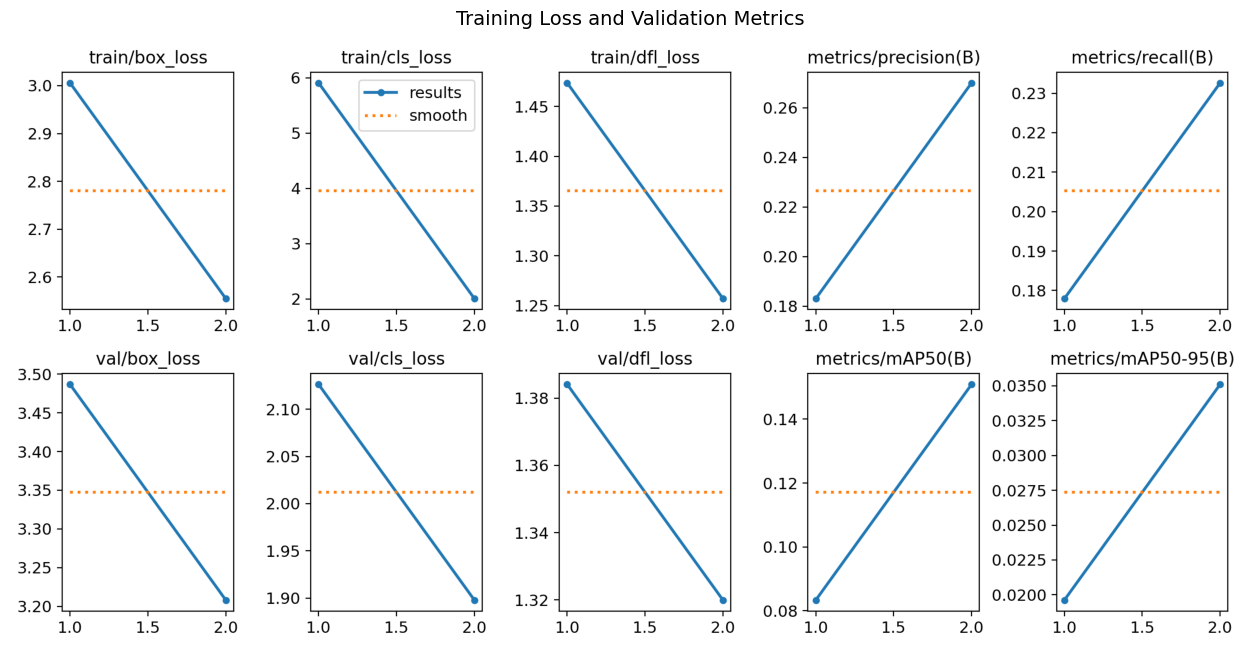

In [17]:
import os
import glob
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Automatically find the newest best.pt across any run folder
candidate_weights = glob.glob("/kaggle/working/runs_sar/**/weights/best.pt", recursive=True)

if candidate_weights:
    # Pick the most recently created best.pt
    best_weights = max(candidate_weights, key=os.path.getmtime)
    print(f"--> Found trained checkpoint: {best_weights}")
else:
    # Check if a last.pt exists (in case training was stopped early)
    last_weights = glob.glob("/kaggle/working/runs_sar/**/weights/last.pt", recursive=True)
    if last_weights:
        best_weights = max(last_weights, key=os.path.getmtime)
        print(f"--> Notice: best.pt not found, using last.pt: {best_weights}")
    else:
        print("--> WARNING: No trained weights found yet. Defaulting to base yolov8m.pt")
        best_weights = "yolov8m.pt"

# 2. Load model
sar_model = YOLO(best_weights)

# 3. Run validation benchmark
metrics = sar_model.val(data=sar_yaml_path, imgsz=1024, split="val", device=0)

print("\n" + "="*45)
print("       UAV SURVIVOR DETECTION BENCHMARK")
print("="*45)
print(f"mAP @ 0.50 (IoU 50%):            {metrics.box.map50:.4f}")
print(f"mAP @ 0.50:0.95 (Strict IoU):    {metrics.box.map:.4f}")
print(f"Precision:                       {metrics.box.mp:.4f}")
print(f"Recall:                          {metrics.box.mr:.4f}")
print("="*45 + "\n")

# 4. Display results plot if available in the run folder
run_folder = os.path.dirname(os.path.dirname(best_weights)) if best_weights.endswith(".pt") else ""
results_plot_path = os.path.join(run_folder, "results.png")

if os.path.exists(results_plot_path):
    plot_img = cv2.imread(results_plot_path)
    plt.figure(figsize=(16, 10))
    plt.imshow(cv2.cvtColor(plot_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Training Loss and Validation Metrics", fontsize=14)
    plt.show()

In [18]:
import cv2
import torch
import numpy as np

# Input video: use downloaded test video or point to an attached Kaggle MP4
INPUT_VIDEO = "/kaggle/working/drone_feed_input.mp4"
OUTPUT_VIDEO = "/kaggle/working/sar_drone_detected_feed.mp4"

# Ensure an input video exists
if not os.path.exists(INPUT_VIDEO):
    import urllib.request
    print("Downloading sample drone test video...")
    urllib.request.urlretrieve(
        "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4",
        INPUT_VIDEO
    )

cap = cv2.VideoCapture(INPUT_VIDEO)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

print(f"Processing drone stream: {width}x{height} @ {fps:.1f} FPS ({total_frames} total frames)")

frame_idx = 0
MAX_FRAMES = 350  # Process first ~12-14 seconds (set to None for entire video)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or (MAX_FRAMES and frame_idx >= MAX_FRAMES):
        break

    # Run detection + ByteTrack persistence using our trained weights
    results = sar_model.track(
        frame,
        persist=True,
        conf=0.25,
        iou=0.5,
        imgsz=1024,
        device=0,
        verbose=False
    )

    detections = []
    if results[0].boxes is not None and results[0].boxes.xyxy is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int) if results[0].boxes.id is not None else [-1] * len(boxes)
        for box, c, tid in zip(boxes, confs, ids):
            detections.append((box, float(c), int(tid)))

    # Draw survivor targets
    for box, conf, track_id in detections:
        x1, y1, x2, y2 = box
        target_color = (0, 0, 255) if conf > 0.45 else (0, 165, 255)

        # Bounding box & center target marker
        cv2.rectangle(frame, (x1, y1), (x2, y2), target_color, 2)
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        cv2.drawMarker(frame, (cx, cy), target_color, markerType=cv2.MARKER_CROSS, markerSize=10, thickness=1)

        # Survivor tag
        tag = f"SURVIVOR #{track_id} ({conf:.2f})" if track_id != -1 else f"SURVIVOR ({conf:.2f})"
        cv2.putText(frame, tag, (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, target_color, 2)

    # Draw Tactical HUD Overlay
    count = len(detections)
    cv2.rectangle(frame, (15, 15), (380, 105), (15, 15, 15), -1)
    cv2.rectangle(frame, (15, 15), (380, 105), (0, 255, 0) if count > 0 else (120, 120, 120), 2)

    status_msg = "ALERT: SURVIVOR IDENTIFIED" if count > 0 else "SCANNING SECTOR..."
    status_col = (0, 0, 255) if count > 0 else (0, 255, 0)

    cv2.putText(frame, "UAV TACTICAL RESCUE FEED", (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    cv2.putText(frame, status_msg, (30, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.5, status_col, 2)
    cv2.putText(frame, f"TARGETS DETECTED: {count} | FRAME: {frame_idx}", (30, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200, 200, 200), 1)

    out.write(frame)

    if frame_idx % 30 == 0:
        print(f"Rendered frame {frame_idx}/{MAX_FRAMES or total_frames} - Current survivors: {count}")
    frame_idx += 1

cap.release()
out.release()
print(f"\nProcessing complete! Annotated video saved to: {OUTPUT_VIDEO}")

Processing drone stream: 768x432 @ 12.0 FPS (647 total frames)
Rendered frame 0/350 - Current survivors: 0
Rendered frame 30/350 - Current survivors: 0
Rendered frame 60/350 - Current survivors: 0
Rendered frame 90/350 - Current survivors: 0
Rendered frame 120/350 - Current survivors: 0
Rendered frame 150/350 - Current survivors: 0
Rendered frame 180/350 - Current survivors: 0
Rendered frame 210/350 - Current survivors: 0
Rendered frame 240/350 - Current survivors: 0
Rendered frame 270/350 - Current survivors: 0
Rendered frame 300/350 - Current survivors: 0
Rendered frame 330/350 - Current survivors: 0

Processing complete! Annotated video saved to: /kaggle/working/sar_drone_detected_feed.mp4


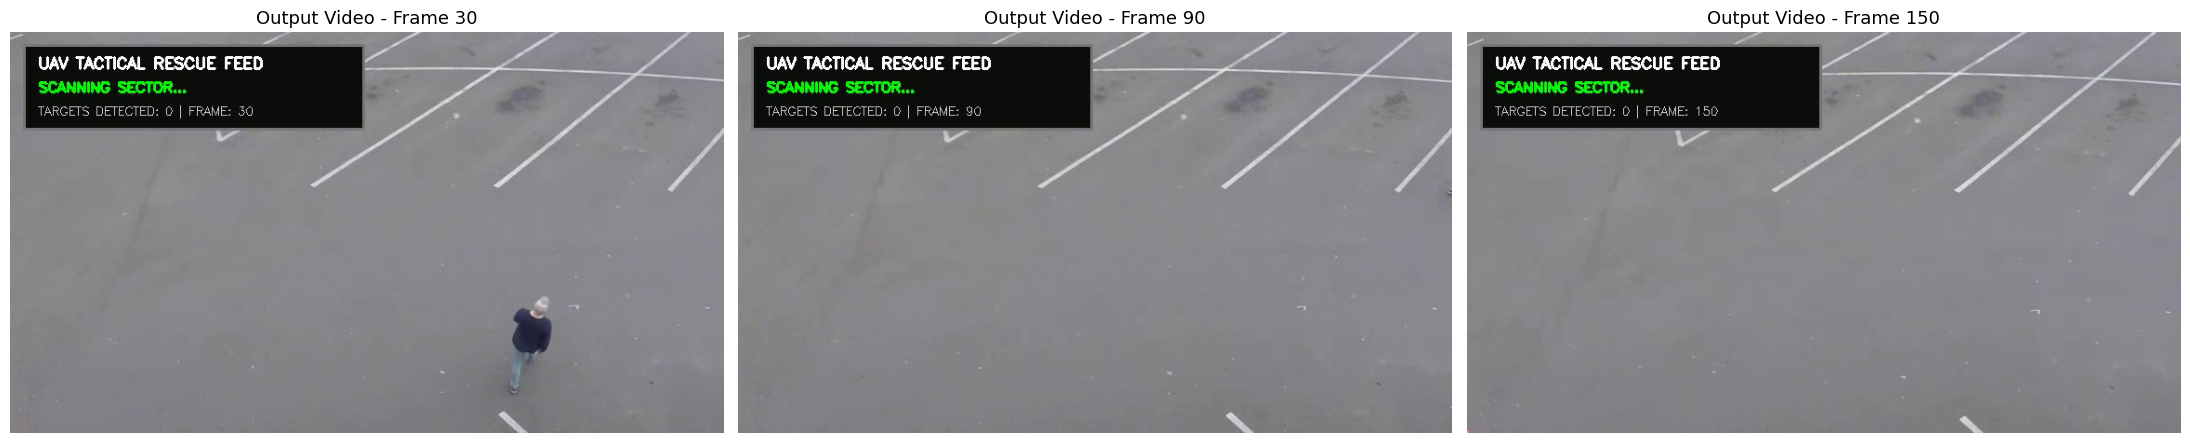


Output video ready for submission download at:
/kaggle/working/sar_drone_detected_feed.mp4


In [19]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(OUTPUT_VIDEO)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

sample_indices = [30, 90, 150]
current_idx = 0
slot = 0

while cap.isOpened() and slot < 3:
    ret, frame = cap.read()
    if not ret:
        break
    if current_idx in sample_indices:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[slot].imshow(frame_rgb)
        axes[slot].set_title(f"Output Video - Frame {current_idx}", fontsize=13)
        axes[slot].axis("off")
        slot += 1
    current_idx += 1

cap.release()
plt.tight_layout()
plt.show()

print("\nOutput video ready for submission download at:")
print("/kaggle/working/sar_drone_detected_feed.mp4")

--> Using weights: yolov8m.pt
--> Testing on image: /kaggle/working/datasets/VisDrone/VisDrone2019-DET-val/images/0000215_02667_d_0000262.jpg

                     DETECTION VERIFICATION TABLE                     
Target ID  | Confidence   | Box (x1, y1, x2, y2)      | Box Size (W x H)
----------------------------------------------------------------------
Survivor #1   |  73.7%       | (1084,  378, 1100,  412)    |  16px x  34px
Survivor #2   |  63.3%       | ( 615,  589,  631,  634)    |  16px x  45px
Survivor #3   |  61.4%       | ( 201,   86,  212,  111)    |  11px x  25px
Survivor #4   |  54.0%       | (  93,  312,  110,  351)    |  17px x  39px
Survivor #5   |  49.4%       | (  94,  100,  105,  125)    |  11px x  25px
Survivor #6   |  46.4%       | ( 104,  308,  118,  346)    |  14px x  38px
Survivor #7   |  43.9%       | ( 608,  375,  624,  410)    |  16px x  35px
Survivor #8   |  42.6%       | (  96,   99,  112,  127)    |  16px x  28px
Survivor #9   |  42.4%       | ( 594,  597

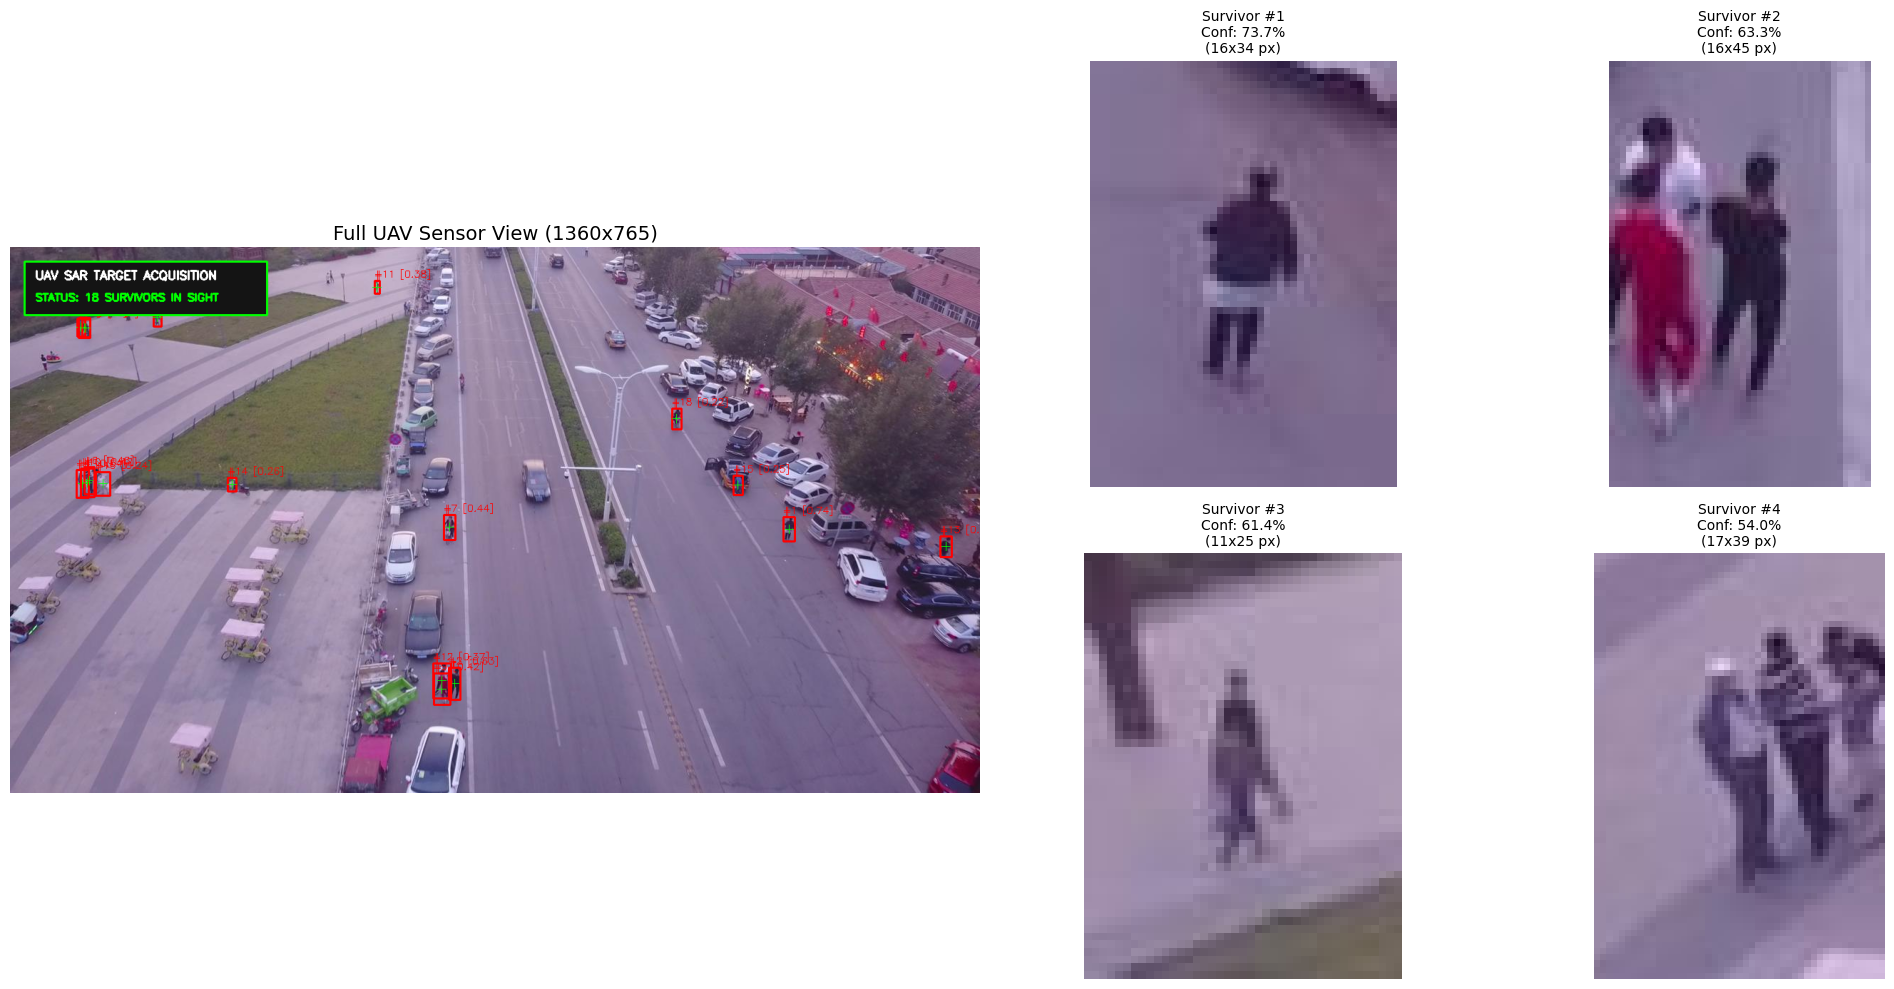

In [20]:
import os
import glob
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Select Model Weights (Custom trained if ready, otherwise base weights)
custom_weights = "/kaggle/working/runs_sar/yolov8m_sar_visdrone/weights/best.pt"
weights_path = custom_weights if os.path.exists(custom_weights) else "yolov8m.pt"
print(f"--> Using weights: {weights_path}")

model = YOLO(weights_path)

# 2. Pick a test aerial image from the validation set (or download a sample if not present)
val_images = glob.glob("/kaggle/working/datasets/VisDrone/VisDrone2019-DET-val/images/*.jpg")

if val_images:
    # Pick a sample image with good survivor density
    sample_img_path = val_images[10]
else:
    # Fallback: grab an aerial drone test image
    sample_img_path = "/kaggle/working/test_drone_aerial.jpg"
    if not os.path.exists(sample_img_path):
        import urllib.request
        test_url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/assets/bus.jpg"
        urllib.request.urlretrieve(test_url, sample_img_path)

print(f"--> Testing on image: {sample_img_path}")

# 3. Run Inference at 1024px
img_bgr = cv2.imread(sample_img_path)
h_orig, w_orig, _ = img_bgr.shape

# If using yolov8m base, filter COCO class 0 (person); if custom best.pt, class 0 is survivor
target_class = [0]
results = model.predict(source=img_bgr, imgsz=1024, conf=0.20, classes=target_class, verbose=False)[0]

# 4. Extract and Print Raw Numerical Predictions (Verification Table)
boxes = results.boxes.xyxy.cpu().numpy().astype(int) if results.boxes is not None else []
confs = results.boxes.conf.cpu().numpy() if results.boxes is not None else []

print("\n" + "="*70)
print(f"{'DETECTION VERIFICATION TABLE':^70}")
print("="*70)
print(f"{'Target ID':<10} | {'Confidence':<12} | {'Box (x1, y1, x2, y2)':<25} | {'Box Size (W x H)':<15}")
print("-"*70)

detections = []
for i, (box, conf) in enumerate(zip(boxes, confs)):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    detections.append((box, conf, bw, bh))
    print(f"Survivor #{i+1:<3} | {conf*100:>5.1f}%       | ({x1:>4}, {y1:>4}, {x2:>4}, {y2:>4})    | {bw:>3}px x {bh:>3}px")

print("="*70)
print(f"Total Verified Targets: {len(detections)}\n")

# 5. Render Visual Verification: Full Drone Context + Zoomed Target Crops
fig = plt.figure(figsize=(20, 10))

# Left Subplot: Full Aerial Frame with Rescue Overlays
canvas = img_bgr.copy()
for i, (box, conf, bw, bh) in enumerate(detections):
    x1, y1, x2, y2 = box
    # Draw bounding box
    cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 0, 255), 2)
    # Draw center crosshair
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    cv2.drawMarker(canvas, (cx, cy), (0, 255, 0), markerType=cv2.MARKER_CROSS, markerSize=12, thickness=1)
    # Tag label
    cv2.putText(canvas, f"#{i+1} [{conf:.2f}]", (x1, max(15, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)

# Tactical Status Box
cv2.rectangle(canvas, (20, 20), (360, 95), (20, 20, 20), -1)
cv2.rectangle(canvas, (20, 20), (360, 95), (0, 255, 0), 2)
cv2.putText(canvas, "UAV SAR TARGET ACQUISITION", (35, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
cv2.putText(canvas, f"STATUS: {len(detections)} SURVIVORS IN SIGHT", (35, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

ax_main = fig.add_subplot(1, 2, 1)
ax_main.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
ax_main.set_title(f"Full UAV Sensor View ({w_orig}x{h_orig})", fontsize=14)
ax_main.axis("off")

# Right Subplots: Zoom Crops of Top 4 Detected Small Targets
crops_to_show = min(4, len(detections))
if crops_to_show > 0:
    for idx in range(crops_to_show):
        box, conf, bw, bh = detections[idx]
        x1, y1, x2, y2 = box
        
        # Add 15px padding around target for context
        pad = 15
        cy1, cy2 = max(0, y1 - pad), min(h_orig, y2 + pad)
        cx1, cx2 = max(0, x1 - pad), min(w_orig, x2 + pad)
        
        crop = cv2.cvtColor(img_bgr[cy1:cy2, cx1:cx2], cv2.COLOR_BGR2RGB)
        
        ax_crop = fig.add_subplot(2, 4, 3 + idx if idx < 2 else 5 + idx)
        ax_crop.imshow(crop)
        ax_crop.set_title(f"Survivor #{idx+1}\nConf: {conf*100:.1f}%\n({bw}x{bh} px)", fontsize=10)
        ax_crop.axis("off")
else:
    print("No targets spotted above the confidence threshold on this specific frame.")

plt.tight_layout()
plt.show()